In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Loan_Default.csv")
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


(148670, 34)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges 

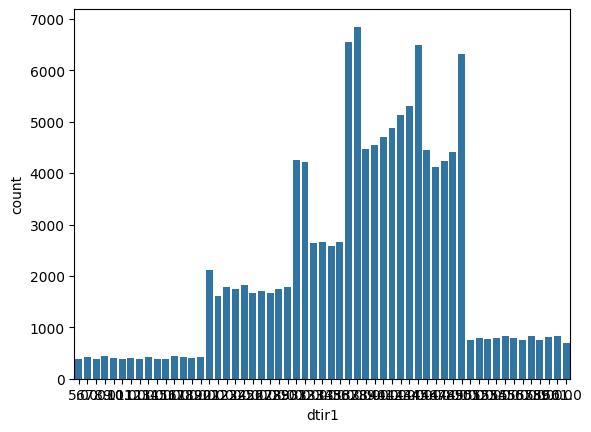

In [26]:
print(df.shape)
df.info()

# Missing values
print(df.isnull().sum())

# Target distribution
target = df.columns[-1]
sns.countplot(x=df[target])
plt.show()

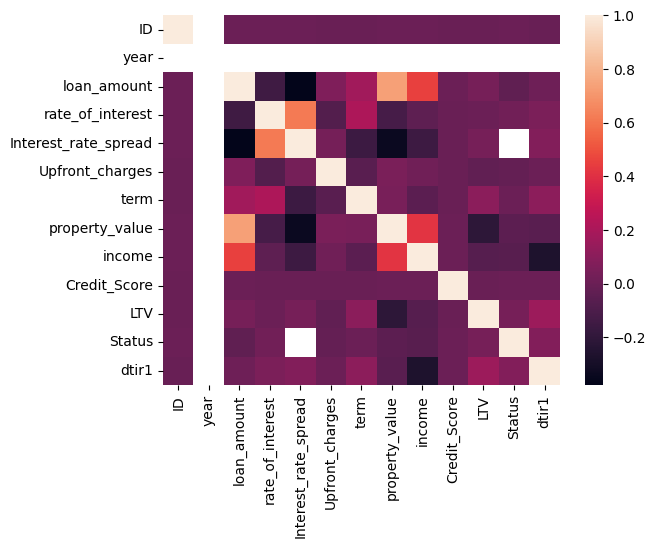

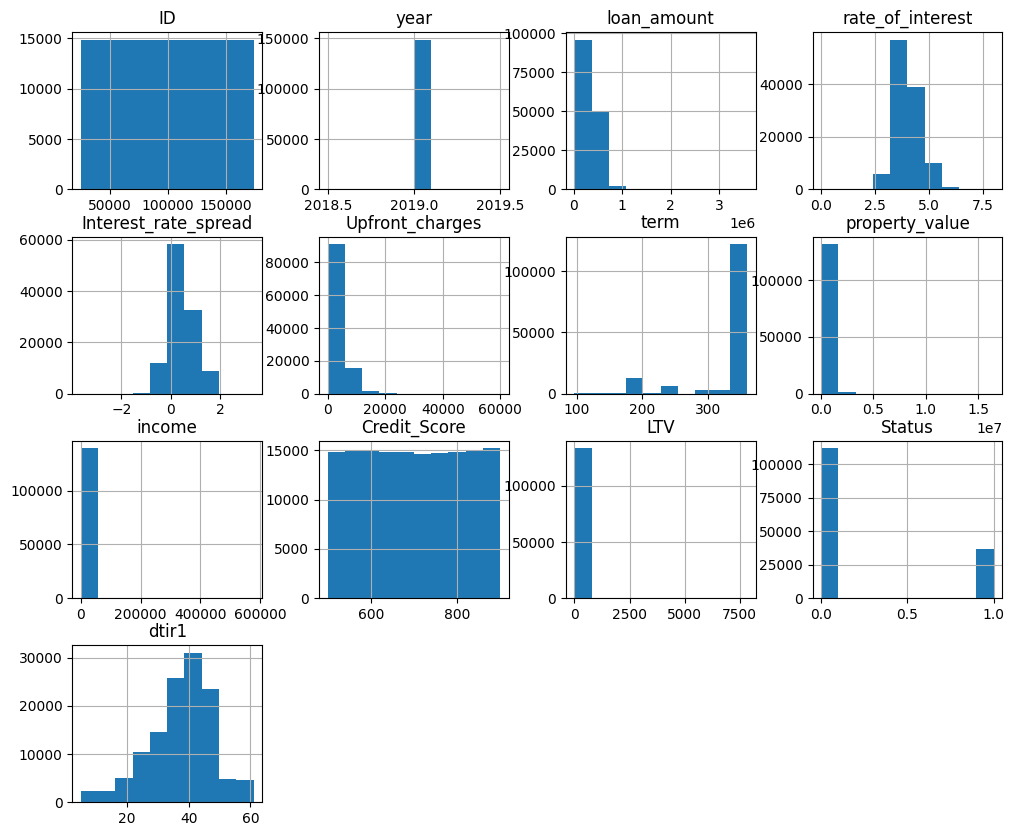

In [27]:
# Correlation
plt.figure()
sns.heatmap(df.corr(numeric_only=True))
plt.show()

# Histograms
df.hist(figsize=(12,10))
plt.show()

In [28]:
df = df.dropna(subset=['Status'])

# Target
y = df['Status'].astype(int)

# Features
X = df.drop(['Status', 'ID','dtir1',
    'rate_of_interest',
    'Interest_rate_spread',
    'Upfront_charges'], axis=1)


print('Status in X:', 'Status' in X.columns)

Status in X: False


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Separate columns
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Handle missing values
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna('Missing')

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])


In [31]:
print(X.columns)

Index(['year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type'],
      dtype='object')


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline(
    [('preprocessing', preprocessor),
     ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))]
)

param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [5, 10],
    'model__min_samples_split': [2, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['year', 'loan_amount', 'term', 'property_value', 'income',
       'Credit_Score', 'LTV'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'Credit_Worthin...
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'credit_type', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'Region', 'Security_Type'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [50, 100]},
             scoring='roc_auc')

In [33]:
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

best_model = grid.best_estimator_

Best Params: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best Score: 0.8588842275934075


In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8602946122284254
[[21090  1404]
 [ 2750  4490]]
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     22494
           1       0.76      0.62      0.68      7240

    accuracy                           0.86     29734
   macro avg       0.82      0.78      0.80     29734
weighted avg       0.85      0.86      0.86     29734



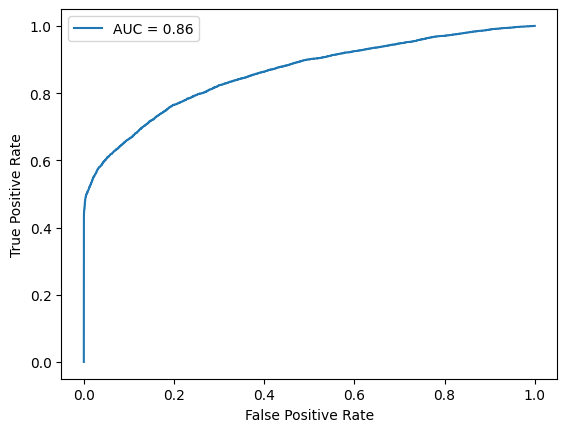

In [35]:
from sklearn.metrics import roc_curve, auc

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

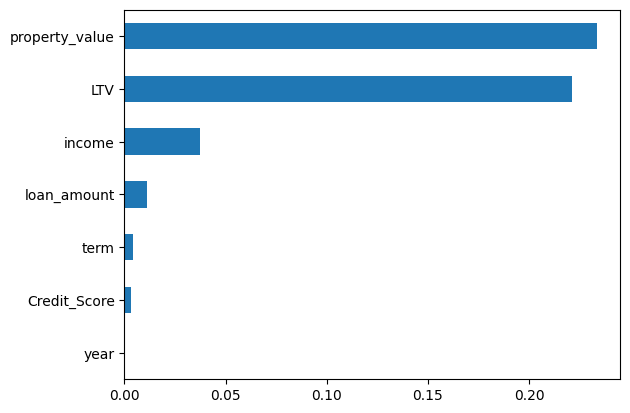

In [36]:
model = best_model.named_steps['model']

importances = model.feature_importances_

features = num_cols  # simplified

feat_imp = pd.Series(importances[:len(features)], index=features)
feat_imp.sort_values().plot(kind='barh')
plt.show()

In [37]:
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [38]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:54:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [39]:
from sklearn.metrics import accuracy_score, roc_auc_score

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_prob))

XGBoost Accuracy: 0.8850474204614246
XGBoost ROC-AUC: 0.8750792568626033


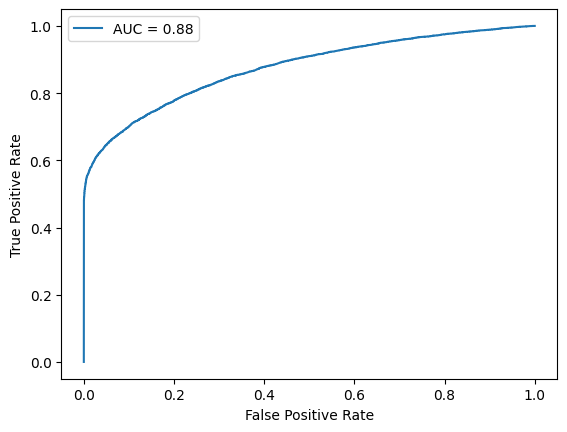

In [40]:
y_prob = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

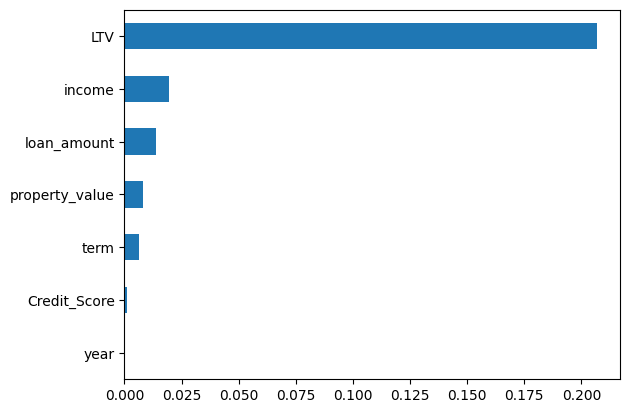

In [41]:
model = xgb_model.named_steps['model']

importances = model.feature_importances_

features = num_cols

feat_imp = pd.Series(importances[:len(features)], index=features)
feat_imp.sort_values().plot(kind='barh')
plt.show()

In [42]:
import joblib

# Save trained pipeline
joblib.dump(best_model, "model.pkl")

# Save schema
joblib.dump(X.columns, "columns.pkl")
joblib.dump(X.dtypes, "dtypes.pkl")

print("Files saved successfully!")

Files saved successfully!


In [43]:
from google.colab import files

#files.download("model.pkl")
# files.download("columns.pkl")
# files.download("dtypes.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
# Install pyngrok, a Python wrapper for ngrok
!pip install pyngrok

### Set up ngrok Authentication Token

To use `ngrok`, you'll need an authentication token. Follow these steps:

1.  **Sign up for a free ngrok account:** Visit [ngrok.com](https://ngrok.com/signup).
2.  **Get your Authtoken:** After signing up, go to your dashboard and find your Authtoken (e.g., `2iJd...`).
3.  **Add to Colab Secrets:** In Colab, click the "🔑" icon on the left sidebar (Secrets panel). Add a new secret with the name `NGROK_AUTH_TOKEN` and paste your `ngrok` Authtoken as the value. Make sure to enable "Notebook access" for this secret.

Once your token is set, the next cell will use it to establish the tunnel.

In [45]:
import joblib

joblib.dump(X.columns, "columns.pkl")
joblib.dump(X.dtypes, "dtypes.pkl")

['dtypes.pkl']

In [46]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load files
model = joblib.load("model.pkl")
train_cols = joblib.load("columns.pkl")
train_dtypes = joblib.load("dtypes.pkl")

st.title("Loan Default Predictor")

st.header("Enter Loan Details")

# Inputs
age = st.number_input("Age", value=30)
income = st.number_input("Income", value=100000)
loan_amount = st.number_input("Loan Amount", value=200000)
credit_score = st.number_input("Credit Score", value=750)

gender = st.selectbox("Gender", ['Male', 'Female', 'Joint', 'Sex Not Available'])
loan_type = st.selectbox("Loan Type", ['type1', 'type2', 'type3'])
loan_purpose = st.selectbox("Loan Purpose", ['p1', 'p2', 'p3', 'p4'])

if st.button("Predict"):

    # Create input with correct schema
    input_data = pd.DataFrame(columns=train_cols)

    input_data.loc[0, 'age'] = age
    input_data.loc[0, 'income'] = income
    input_data.loc[0, 'loan_amount'] = loan_amount
    input_data.loc[0, 'Credit_Score'] = credit_score
    input_data.loc[0, 'Gender'] = gender
    input_data.loc[0, 'loan_type'] = loan_type
    input_data.loc[0, 'loan_purpose'] = loan_purpose

    # Fill missing + match types
    for col in input_data.columns:
        if train_dtypes[col] == 'object':
            input_data[col] = input_data[col].fillna('Missing').astype(str)
        else:
            input_data[col] = pd.to_numeric(input_data[col], errors='coerce')
            input_data[col] = input_data[col].fillna(0)

    input_data = input_data.astype(train_dtypes)

    pred = model.predict(input_data)

    if pred[0] == 1:
        st.error("Loan will Default")
    else:
        st.success("Loan will NOT Default")

Overwriting app.py


In [47]:
from pyngrok import ngrok
from google.colab import userdata
import subprocess
import os
import time

# Terminate any existing ngrok tunnels
ngrok.kill()

# Get ngrok authtoken from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
if not NGROK_AUTH_TOKEN:
    print("NGROK_AUTH_TOKEN not found in Colab secrets. Please set it up as instructed.")
else:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)

    # Start ngrok tunnel for port 8501 (Streamlit's default port)
    try:
        public_url = ngrok.connect(8501)
        print(f"Streamlit App URL: {public_url}")

        # Run Streamlit in the background and capture output to a log file
        with open('streamlit_logs.txt', 'w') as log_file:
            subprocess.Popen(['nohup', 'python', '-m', 'streamlit', 'run', 'app.py', '&'], stdout=log_file, stderr=log_file)
        print("Streamlit app is starting in the background. Check 'streamlit_logs.txt' for output.")
        print("Please wait a few seconds and then open the URL provided above.")

    except Exception as e:
        print(f"Error starting ngrok tunnel or Streamlit: {e}")
        print("Please ensure you have set your NGROK_AUTH_TOKEN correctly and try again.")

Streamlit App URL: NgrokTunnel: "https://ayden-sustentational-sottishly.ngrok-free.dev" -> "http://localhost:8501"
Streamlit app is starting in the background. Check 'streamlit_logs.txt' for output.
Please wait a few seconds and then open the URL provided above.


In [48]:
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
joblib
xgboost

Overwriting requirements.txt


In [50]:
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
!pip install -r requirements.txt

In [52]:
with open('streamlit_logs.txt', 'r') as f:
    logs = f.read()
print(logs)




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.106.28.116:8502


